# 03 — Signal-to-Noise Ratio & Speech / Silence Segmentation

This notebook covers two topics the professor specifically mentioned:

1. **Signal-to-Noise Ratio (SNR):** How much of the signal is useful speech vs background noise?
2. **Speech vs Silence segmentation:** Where in the recording is someone speaking, and where are the pauses?

Both are critical for Parkinson's speech analysis because:
- PD patients produce **longer and more frequent pauses** (ParkCeleb, p=0.04)
- PD patients have **reduced speech rate** (ParkCeleb, p=0.002)
- Pause patterns can be an early biomarker even before clinical diagnosis

---

## Background: What is SNR?

**Signal-to-Noise Ratio** measures how much louder the desired signal (speech) is  
compared to the background noise. It's expressed in decibels:

$$\text{SNR (dB)} = 10 \cdot \log_{10} \left( \frac{P_{\text{signal}}}{P_{\text{noise}}} \right)$$

where $P$ is the average power (mean of squared amplitudes).

| SNR (dB) | Interpretation |
|----------|----------------|
| > 40 dB  | Very clean (studio quality) |
| 20–40 dB | Good (quiet room, close microphone) |
| 10–20 dB | Moderate (noticeable background noise) |
| < 10 dB  | Poor (noisy environment, distant microphone) |

The KCL dataset was recorded with a smartphone held to the ear, so we expect  
relatively clean recordings (the dataset description claims ~20–40 dB SNR).

---

In [1]:
WAV_FILE = '../KCL/SpontaneousDialogue/PD/ID02_pd_2_0_0.wav'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import librosa
import librosa.display
import parselmouth
from scipy import ndimage
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
})

In [3]:
# ============================================================
# Load audio
# ============================================================
assert os.path.isfile(WAV_FILE), f'File not found: {WAV_FILE}'
fname = os.path.basename(WAV_FILE)

y, sr = librosa.load(WAV_FILE, sr=None)
duration = len(y) / sr
time_axis = np.arange(len(y)) / sr

frame_length = int(sr * 0.025)  # 25 ms
hop_length   = int(sr * 0.010)  # 10 ms

print(f'Loaded: {fname}  |  {sr} Hz  |  {duration:.2f} s')

Loaded: ID02_pd_2_0_0.wav  |  44100 Hz  |  189.38 s


---
## Part 1: Voice Activity Detection (VAD)

Before we can compute SNR or analyse pauses, we need to figure out  
**which parts of the recording contain speech** and **which parts are silence/noise**.

This process is called **Voice Activity Detection (VAD)**.

### Approach: energy-based thresholding

The simplest and most transparent method:
1. Compute the RMS energy of each frame
2. Convert to decibels
3. Set a threshold: frames above it = **speech**, frames below = **silence/noise**
4. Smooth the result to avoid flickering (isolated 1-frame detections)

### How to choose the threshold?
A common approach: take the **median energy of the quietest 10% of frames**  
as the noise floor estimate, then set the threshold some dB above that.

This is not the only way — more advanced methods exist (WebRTC VAD,  
neural VAD like Silero) — but energy-based VAD is fully transparent,  
reproducible, and sufficient for clean recordings like KCL.

In [5]:
# ============================================================
# 1.1  Compute RMS energy in dB
# ============================================================
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
rms_db = 20 * np.log10(rms + 1e-10)
rms_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

print(f'Computed RMS for {len(rms)} frames')
print(f'RMS range: {rms_db.min():.1f} dB to {rms_db.max():.1f} dB')

Computed RMS for 18939 frames
RMS range: -70.5 dB to -14.2 dB


In [6]:
# ============================================================
# 1.2  Estimate noise floor & set threshold
# ============================================================

# Sort energy values and take the bottom 10% as noise estimate
sorted_rms_db = np.sort(rms_db)
n_noise_frames = max(1, int(len(sorted_rms_db) * 0.10))
noise_floor_db = np.median(sorted_rms_db[:n_noise_frames])

# Threshold = noise floor + margin
# 15 dB above noise floor is a reasonable starting point
THRESHOLD_MARGIN_DB = 15
vad_threshold_db = noise_floor_db + THRESHOLD_MARGIN_DB

print(f'Noise floor estimate : {noise_floor_db:.1f} dB  (median of quietest 10% of frames)')
print(f'Threshold margin     : +{THRESHOLD_MARGIN_DB} dB')
print(f'VAD threshold        : {vad_threshold_db:.1f} dB')
print(f'\nFrames above threshold → speech')
print(f'Frames below threshold → silence / noise')

Noise floor estimate : -66.0 dB  (median of quietest 10% of frames)
Threshold margin     : +15 dB
VAD threshold        : -51.0 dB

Frames above threshold → speech
Frames below threshold → silence / noise


In [7]:
# ============================================================
# 1.3  Apply threshold & smooth
# ============================================================

# Raw VAD decision: 1 = speech, 0 = silence
vad_raw = (rms_db >= vad_threshold_db).astype(float)

# Smooth with median filter to remove isolated blips
# A 5-frame median filter spans ~50 ms — removes detections shorter than that
SMOOTH_FRAMES = 5
vad_smooth = ndimage.median_filter(vad_raw, size=SMOOTH_FRAMES)

# Further smoothing: fill short gaps (pauses < 200 ms are probably not real pauses)
MIN_SILENCE_MS = 200
min_silence_frames = int(MIN_SILENCE_MS / (hop_length / sr * 1000))

# Close small gaps: dilate then erode (morphological closing)
vad_closed = ndimage.binary_closing(vad_smooth, structure=np.ones(min_silence_frames)).astype(float)

# Remove short speech bursts (< 100 ms are probably noise)
MIN_SPEECH_MS = 100
min_speech_frames = int(MIN_SPEECH_MS / (hop_length / sr * 1000))
vad_final = ndimage.binary_opening(vad_closed, structure=np.ones(min_speech_frames)).astype(float)

speech_fraction = vad_final.mean()
silence_fraction = 1 - speech_fraction

print(f'VAD result:')
print(f'  Speech  : {speech_fraction:.1%} of recording')
print(f'  Silence : {silence_fraction:.1%} of recording')

VAD result:
  Speech  : 60.9% of recording
  Silence : 39.1% of recording


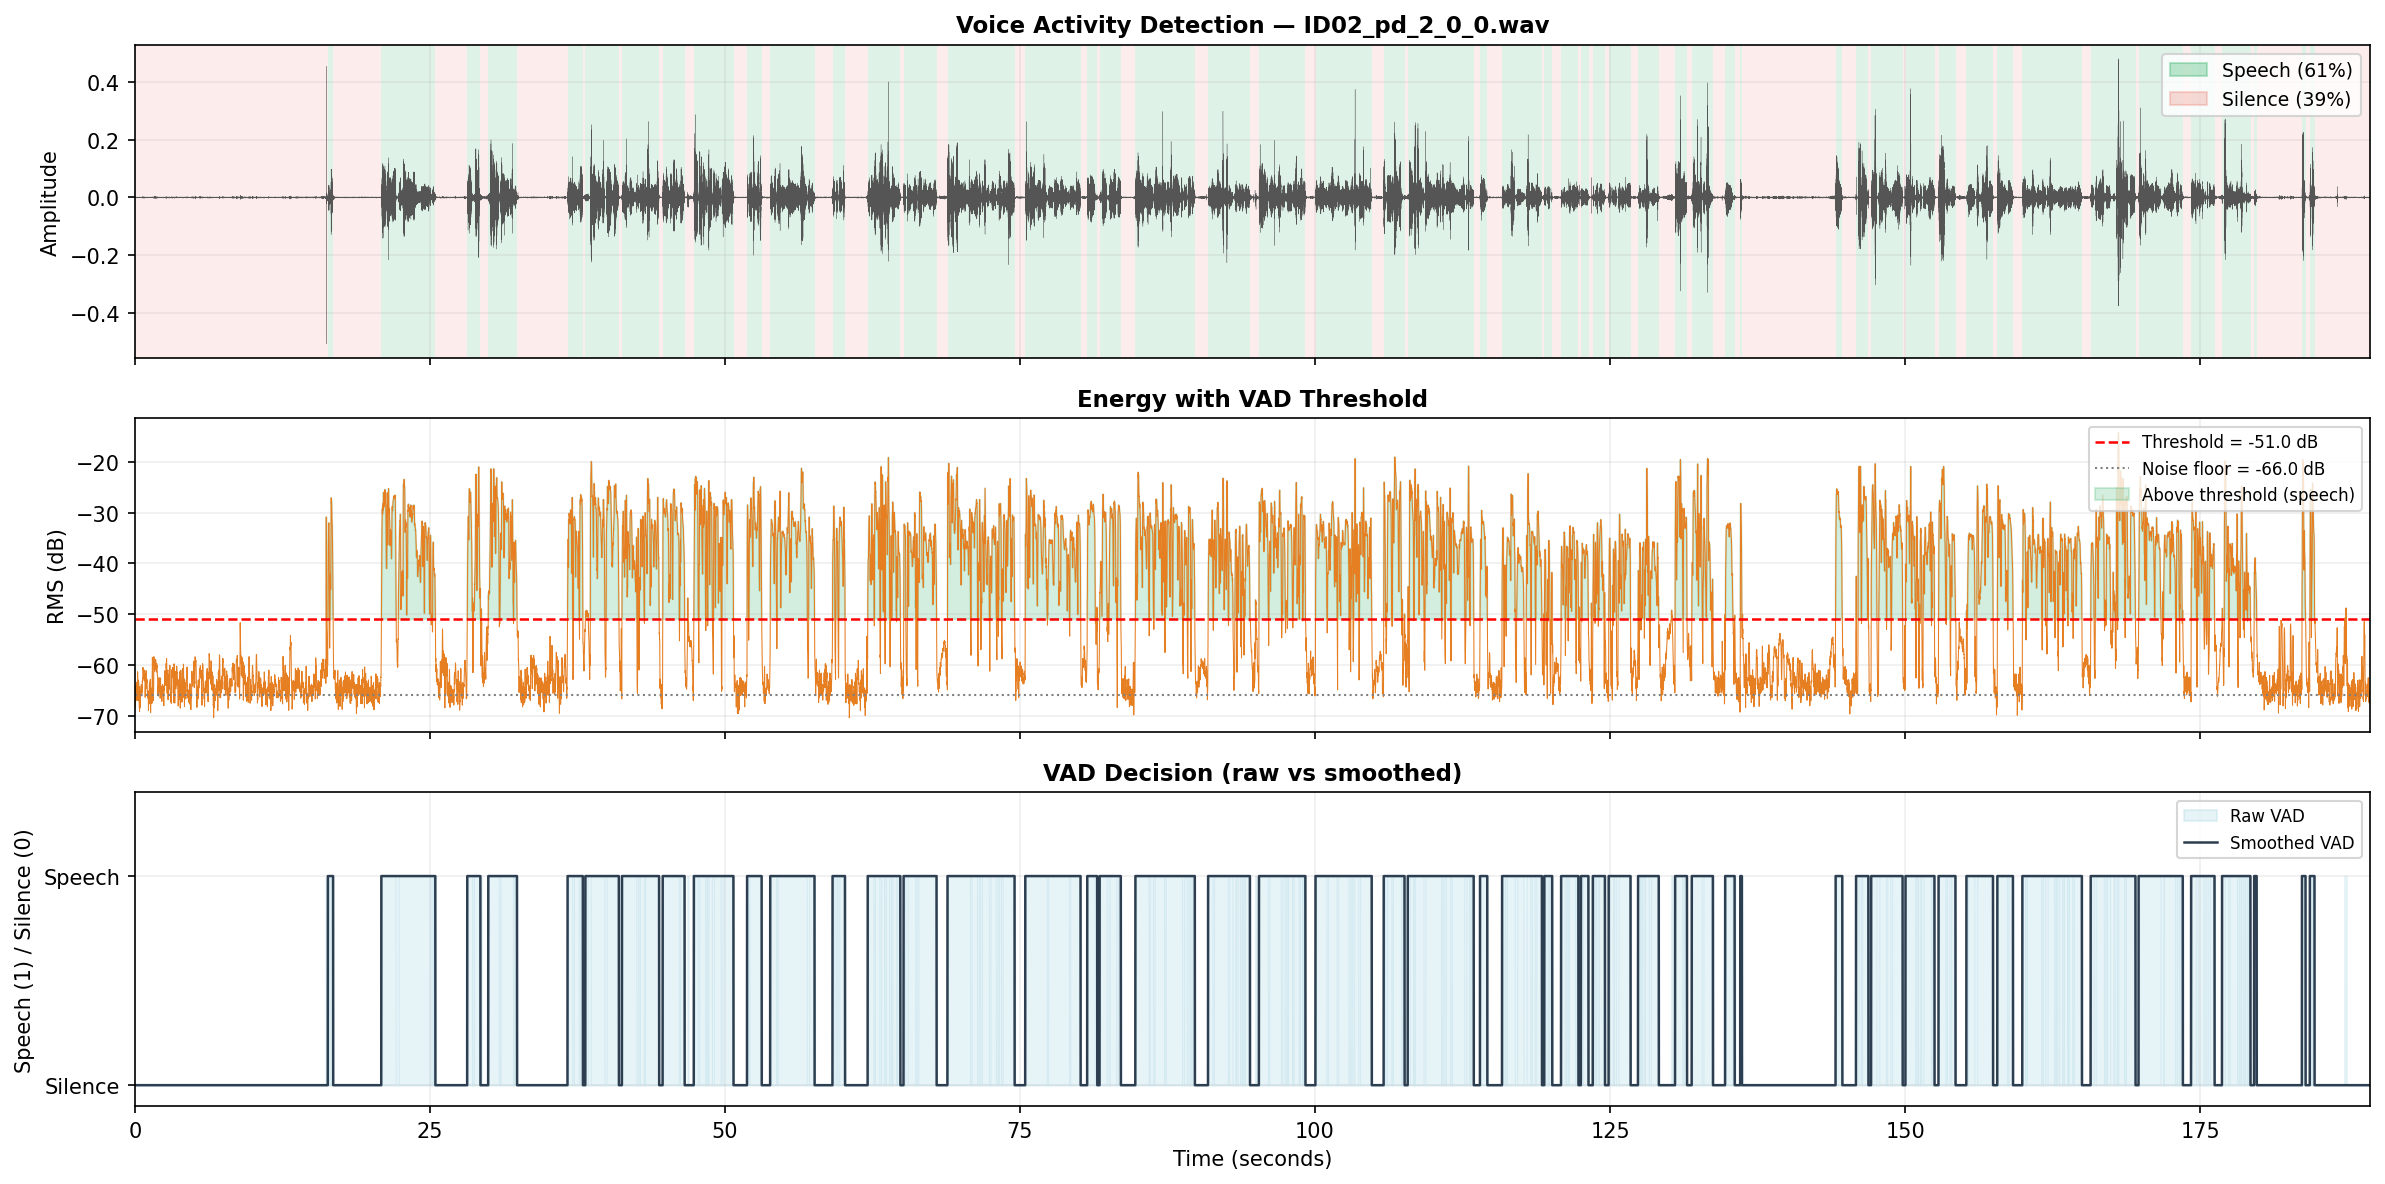

In [8]:
# ============================================================
# 1.4  Visualise VAD result
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

# Panel 1: Waveform with speech/silence overlay
ax = axes[0]
ax.plot(time_axis, y, linewidth=0.15, color='#555555')

# Shade speech regions in green, silence in red
for i in range(len(vad_final)):
    t_start = rms_times[i]
    t_end   = t_start + hop_length / sr
    if vad_final[i] > 0.5:
        ax.axvspan(t_start, t_end, alpha=0.15, color='#27AE60', linewidth=0)
    else:
        ax.axvspan(t_start, t_end, alpha=0.10, color='#E74C3C', linewidth=0)

speech_patch = mpatches.Patch(color='#27AE60', alpha=0.3, label=f'Speech ({speech_fraction:.0%})')
silence_patch = mpatches.Patch(color='#E74C3C', alpha=0.2, label=f'Silence ({silence_fraction:.0%})')
ax.legend(handles=[speech_patch, silence_patch], loc='upper right', fontsize=9)
ax.set_ylabel('Amplitude')
ax.set_title(f'Voice Activity Detection — {fname}')
ax.set_xlim(0, duration)

# Panel 2: RMS energy with threshold line
ax = axes[1]
ax.plot(rms_times, rms_db, linewidth=0.5, color='#E67E22')
ax.axhline(vad_threshold_db, color='red', linestyle='--', linewidth=1.2,
           label=f'Threshold = {vad_threshold_db:.1f} dB')
ax.axhline(noise_floor_db, color='gray', linestyle=':', linewidth=1,
           label=f'Noise floor = {noise_floor_db:.1f} dB')
ax.fill_between(rms_times, rms_db, vad_threshold_db,
                where=(rms_db >= vad_threshold_db),
                alpha=0.2, color='#27AE60', label='Above threshold (speech)')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylabel('RMS (dB)')
ax.set_title('Energy with VAD Threshold')

# Panel 3: Binary VAD timeline
ax = axes[2]
ax.fill_between(rms_times, 0, vad_raw, alpha=0.3, color='lightblue', label='Raw VAD')
ax.plot(rms_times, vad_final, linewidth=1.2, color='#2C3E50', label='Smoothed VAD')
ax.set_ylabel('Speech (1) / Silence (0)')
ax.set_xlabel('Time (seconds)')
ax.set_title('VAD Decision (raw vs smoothed)')
ax.set_ylim(-0.1, 1.4)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Silence', 'Speech'])
ax.legend(loc='upper right', fontsize=8)

for a in axes:
    a.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## Part 2: Signal-to-Noise Ratio (SNR)

Now that we have identified which frames are speech and which are silence/noise,  
we can compute the SNR.

### Method
1. Use the VAD labels to separate frames into **speech** and **noise** categories
2. Compute the average power of each category
3. SNR = 10 × log₁₀(P_speech / P_noise)

### Important caveat
This is an **estimated** SNR because our noise estimate comes from silence regions.  
During speech, the actual noise level might be different (e.g., mouth breathing,  
lip smacks). But for the KCL dataset with controlled conditions, this is reasonable.

In [9]:
# ============================================================
# 2.1  Compute SNR
# ============================================================

# Map VAD decisions back to sample-level
# Each VAD frame covers hop_length samples starting at frame_index * hop_length
speech_mask = np.zeros(len(y), dtype=bool)
for i in range(len(vad_final)):
    if vad_final[i] > 0.5:
        start = i * hop_length
        end   = min(start + frame_length, len(y))
        speech_mask[start:end] = True

noise_mask = ~speech_mask

# Extract speech and noise samples
speech_samples = y[speech_mask]
noise_samples  = y[noise_mask]

# Compute power (mean of squared amplitudes)
P_speech = np.mean(speech_samples ** 2) if len(speech_samples) > 0 else 1e-20
P_noise  = np.mean(noise_samples ** 2)  if len(noise_samples) > 0  else 1e-20

# SNR in dB
snr_db = 10 * np.log10(P_speech / P_noise)

print(f'Signal-to-Noise Ratio Estimation')
print(f'================================')
print(f'  Speech samples : {len(speech_samples):>10,} ({len(speech_samples)/len(y):.1%})')
print(f'  Noise samples  : {len(noise_samples):>10,} ({len(noise_samples)/len(y):.1%})')
print(f'')
print(f'  Speech power   : {P_speech:.6f}')
print(f'  Noise power    : {P_noise:.8f}')
print(f'')
print(f'  ┌──────────────────────────────┐')
print(f'  │  SNR = {snr_db:>6.1f} dB              │')
print(f'  └──────────────────────────────┘')
print(f'')
if snr_db > 40:
    quality = 'Excellent (studio quality)'
elif snr_db > 20:
    quality = 'Good (quiet room, close mic)'
elif snr_db > 10:
    quality = 'Moderate (some background noise)'
else:
    quality = 'Poor (noisy environment)'
print(f'  Assessment: {quality}')

Signal-to-Noise Ratio Estimation
  Speech samples :  5,119,323 (61.3%)
  Noise samples  :  3,232,524 (38.7%)

  Speech power   : 0.000651
  Noise power    : 0.00000111

  ┌──────────────────────────────┐
  │  SNR =   27.7 dB              │
  └──────────────────────────────┘

  Assessment: Good (quiet room, close mic)


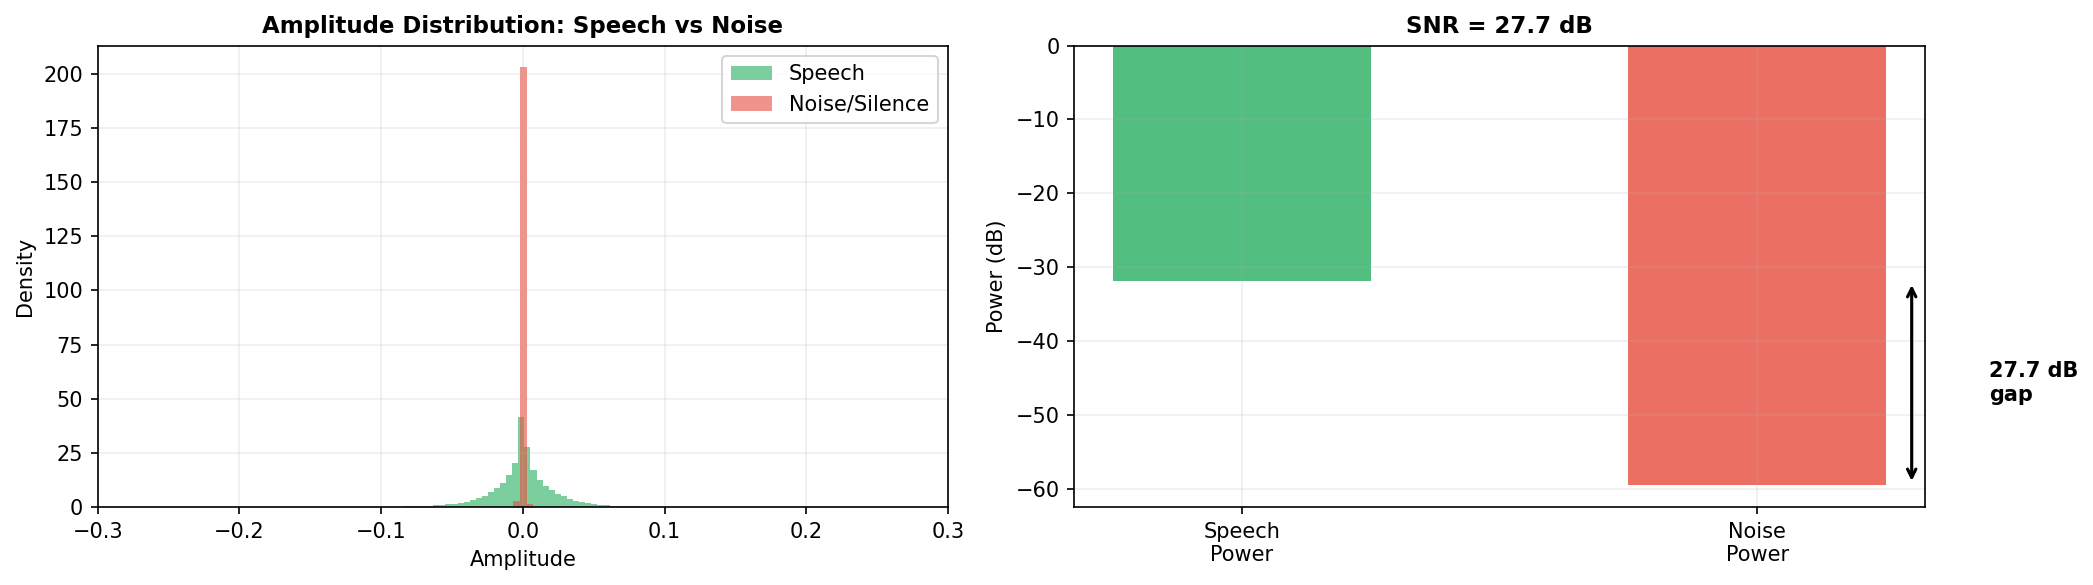

In [10]:
# ============================================================
# 2.2  Visualise speech vs noise distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: amplitude histograms
ax = axes[0]
ax.hist(speech_samples, bins=200, alpha=0.6, color='#27AE60', label='Speech', density=True)
ax.hist(noise_samples, bins=200, alpha=0.6, color='#E74C3C', label='Noise/Silence', density=True)
ax.set_xlabel('Amplitude')
ax.set_ylabel('Density')
ax.set_title('Amplitude Distribution: Speech vs Noise')
ax.legend()
ax.set_xlim(-0.3, 0.3)

# Right: power comparison bar chart
ax = axes[1]
speech_db = 10 * np.log10(P_speech + 1e-20)
noise_db  = 10 * np.log10(P_noise + 1e-20)
bars = ax.bar(['Speech\nPower', 'Noise\nPower'], [speech_db, noise_db],
              color=['#27AE60', '#E74C3C'], alpha=0.8, width=0.5)
ax.set_ylabel('Power (dB)')
ax.set_title(f'SNR = {snr_db:.1f} dB')

# Annotate the difference
ax.annotate('', xy=(1.3, speech_db), xytext=(1.3, noise_db),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(1.45, (speech_db + noise_db) / 2, f'{snr_db:.1f} dB\ngap',
        ha='left', va='center', fontsize=10, fontweight='bold')

for a in axes:
    a.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## Part 3: Pause Analysis

Now let's extract **every individual pause** from the recording  
and compute statistics that are directly relevant for PD detection.

### Metrics we'll compute
| Metric | What it means | PD expectation |
|--------|--------------|----------------|
| Total speech time | Time spent actually speaking | ↓ May decrease |
| Total pause time | Time spent in silence | ↑ Increases |
| Pause-to-speech ratio | pause_time / speech_time | ↑ Increases |
| Number of pauses | How often the speaker stops | ↑ Increases |
| Mean pause duration | Average length of each pause | ↑ Increases (ParkCeleb p=0.04) |
| Max pause duration | Longest single pause | ↑ May increase |
| Pause rate | Pauses per second of speech | ↑ Increases |
| Speech rate proxy | Speech frames per second | ↓ Decreases |

In [11]:
# ============================================================
# 3.1  Extract individual speech and silence segments
# ============================================================

def extract_segments(vad_array, times, hop_sec):
    """
    Given a binary VAD array (1=speech, 0=silence),
    extract the start time, end time, and duration of each
    contiguous speech and silence segment.
    """
    segments = []
    if len(vad_array) == 0:
        return segments
    
    current_state = vad_array[0]
    seg_start = times[0]
    
    for i in range(1, len(vad_array)):
        if vad_array[i] != current_state:
            # State changed — close current segment
            seg_end = times[i]
            label = 'speech' if current_state > 0.5 else 'silence'
            segments.append({
                'type': label,
                'start': seg_start,
                'end': seg_end,
                'duration': seg_end - seg_start
            })
            # Start new segment
            current_state = vad_array[i]
            seg_start = times[i]
    
    # Close final segment
    seg_end = times[-1] + hop_sec
    label = 'speech' if current_state > 0.5 else 'silence'
    segments.append({
        'type': label,
        'start': seg_start,
        'end': seg_end,
        'duration': seg_end - seg_start
    })
    
    return segments


hop_sec = hop_length / sr
segments = extract_segments(vad_final, rms_times, hop_sec)

speech_segs  = [s for s in segments if s['type'] == 'speech']
silence_segs = [s for s in segments if s['type'] == 'silence']

print(f'Detected {len(speech_segs)} speech segments and {len(silence_segs)} silence segments')
print(f'\nFirst 10 segments:')
for s in segments[:10]:
    bar = '█' if s['type'] == 'speech' else '░'
    print(f"  {bar} {s['type']:>8s}  {s['start']:6.2f}s – {s['end']:6.2f}s  ({s['duration']:.3f}s)")

Detected 51 speech segments and 52 silence segments

First 10 segments:
  ░  silence    0.00s –  16.36s  (16.360s)
  █   speech   16.36s –  16.81s  (0.450s)
  ░  silence   16.81s –  20.89s  (4.080s)
  █   speech   20.89s –  25.47s  (4.580s)
  ░  silence   25.47s –  28.17s  (2.700s)
  █   speech   28.17s –  29.29s  (1.120s)
  ░  silence   29.29s –  29.95s  (0.660s)
  █   speech   29.95s –  32.39s  (2.440s)
  ░  silence   32.39s –  36.67s  (4.280s)
  █   speech   36.67s –  37.97s  (1.300s)


In [12]:
# ============================================================
# 3.2  Compute pause statistics
# ============================================================
speech_durations  = np.array([s['duration'] for s in speech_segs])
silence_durations = np.array([s['duration'] for s in silence_segs])

total_speech  = speech_durations.sum()
total_silence = silence_durations.sum()
total_time    = total_speech + total_silence

# Filter out leading/trailing silence (only count internal pauses)
# Internal pauses = silence segments that are NOT the first or last segment
internal_pauses = []
for i, s in enumerate(segments):
    if s['type'] == 'silence' and i > 0 and i < len(segments) - 1:
        internal_pauses.append(s['duration'])
internal_pauses = np.array(internal_pauses)

print('┌─────────────────────────────────────────────────────────┐')
print(f'│  Pause Analysis: {fname:<39s} │')
print('├─────────────────────────────────────────────────────────┤')
print(f'│                                                         │')
print(f'│  Total duration        : {total_time:>8.2f} s                    │')
print(f'│  Total speech time     : {total_speech:>8.2f} s ({total_speech/total_time:.0%})             │')
print(f'│  Total pause time      : {total_silence:>8.2f} s ({total_silence/total_time:.0%})             │')
print(f'│  Pause-to-speech ratio : {total_silence/total_speech:>8.3f}                       │' if total_speech > 0 else '')
print(f'│                                                         │')
print(f'│  Number of pauses      : {len(internal_pauses):>8d}                       │')
if len(internal_pauses) > 0:
    print(f'│  Mean pause duration   : {internal_pauses.mean():>8.3f} s                    │')
    print(f'│  Median pause duration : {np.median(internal_pauses):>8.3f} s                    │')
    print(f'│  Std pause duration    : {internal_pauses.std():>8.3f} s                    │')
    print(f'│  Max pause duration    : {internal_pauses.max():>8.3f} s                    │')
    print(f'│  Min pause duration    : {internal_pauses.min():>8.3f} s                    │')
    print(f'│  Pause rate            : {len(internal_pauses)/total_speech:>8.2f} pauses/s of speech   │' if total_speech > 0 else '')
print(f'│                                                         │')
print(f'│  SNR                   : {snr_db:>8.1f} dB                    │')
print('└─────────────────────────────────────────────────────────┘')

┌─────────────────────────────────────────────────────────┐
│  Pause Analysis: ID02_pd_2_0_0.wav                       │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  Total duration        :   189.39 s                    │
│  Total speech time     :   115.32 s (61%)             │
│  Total pause time      :    74.07 s (39%)             │
│  Pause-to-speech ratio :    0.642                       │
│                                                         │
│  Number of pauses      :       50                       │
│  Mean pause duration   :    1.060 s                    │
│  Median pause duration :    0.710 s                    │
│  Std pause duration    :    1.352 s                    │
│  Max pause duration    :    7.940 s                    │
│  Min pause duration    :    0.200 s                    │
│  Pause rate            :     0.43 pauses/s of speech   │
│                                                 

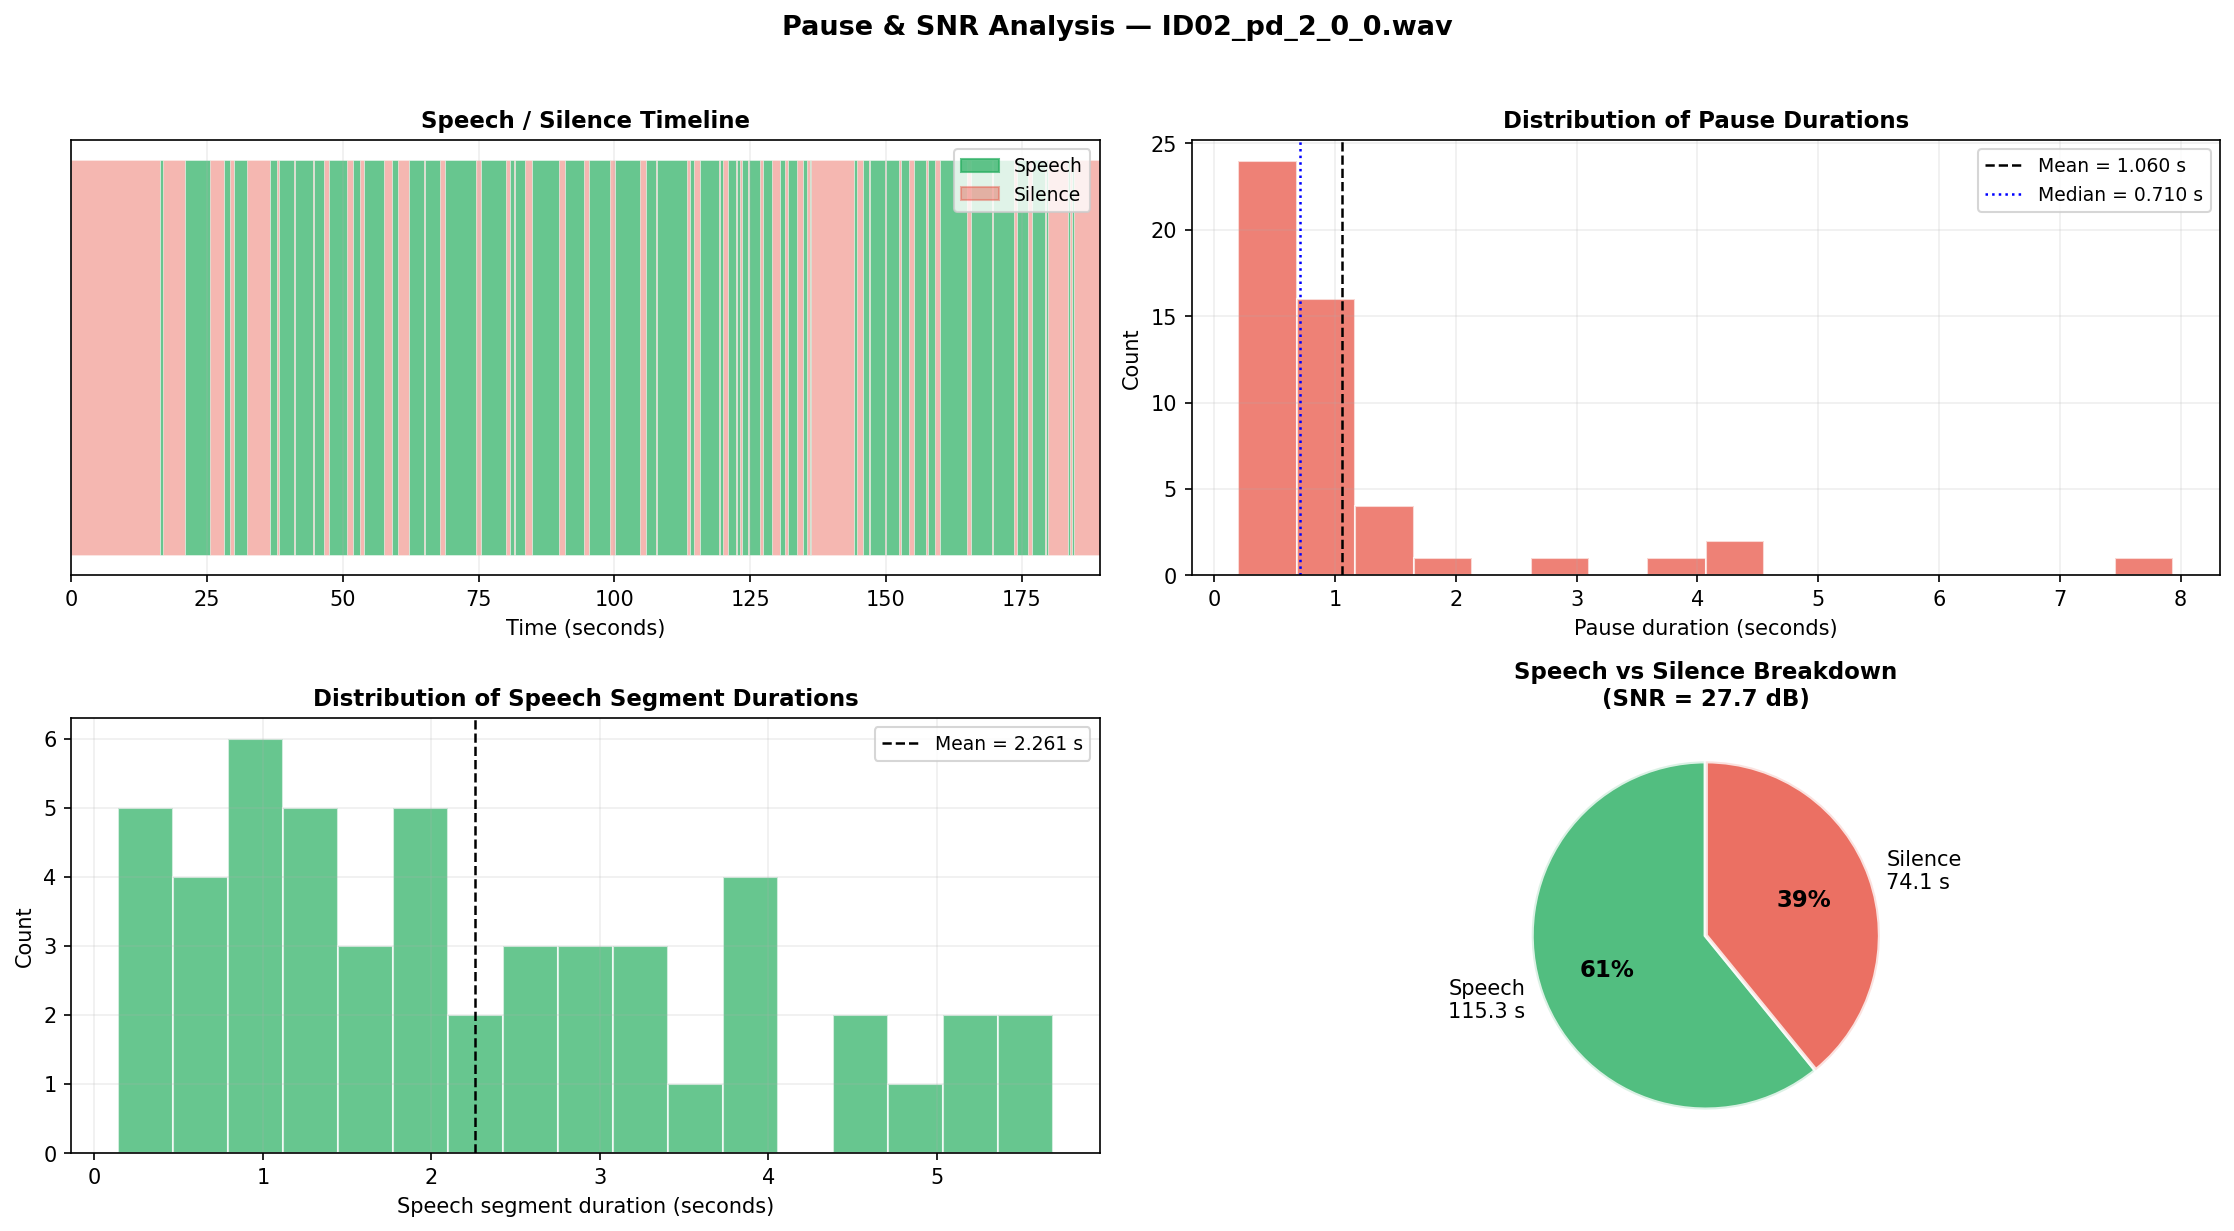

Saved → pause_analysis_ID02_pd_2_0_0.png


In [13]:
# ============================================================
# 3.3  Visualise pause analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# --- Top left: Segment timeline ---
ax = axes[0, 0]
for s in segments:
    color = '#27AE60' if s['type'] == 'speech' else '#E74C3C'
    alpha = 0.7 if s['type'] == 'speech' else 0.4
    ax.barh(0, s['duration'], left=s['start'], height=0.6,
            color=color, alpha=alpha, edgecolor='white', linewidth=0.3)
ax.set_xlim(0, duration)
ax.set_yticks([])
ax.set_xlabel('Time (seconds)')
ax.set_title('Speech / Silence Timeline')
speech_p = mpatches.Patch(color='#27AE60', alpha=0.7, label='Speech')
silence_p = mpatches.Patch(color='#E74C3C', alpha=0.4, label='Silence')
ax.legend(handles=[speech_p, silence_p], loc='upper right', fontsize=9)

# --- Top right: Pause duration histogram ---
ax = axes[0, 1]
if len(internal_pauses) > 0:
    ax.hist(internal_pauses, bins=max(5, len(internal_pauses)//3),
            color='#E74C3C', alpha=0.7, edgecolor='white')
    ax.axvline(internal_pauses.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean = {internal_pauses.mean():.3f} s')
    ax.axvline(np.median(internal_pauses), color='blue', linestyle=':', linewidth=1.2,
               label=f'Median = {np.median(internal_pauses):.3f} s')
    ax.legend(fontsize=9)
ax.set_xlabel('Pause duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pause Durations')

# --- Bottom left: Speech segment duration histogram ---
ax = axes[1, 0]
if len(speech_durations) > 0:
    ax.hist(speech_durations, bins=max(5, len(speech_durations)//3),
            color='#27AE60', alpha=0.7, edgecolor='white')
    ax.axvline(speech_durations.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean = {speech_durations.mean():.3f} s')
    ax.legend(fontsize=9)
ax.set_xlabel('Speech segment duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Speech Segment Durations')

# --- Bottom right: Summary pie chart ---
ax = axes[1, 1]
sizes = [total_speech, total_silence]
labels = [f'Speech\n{total_speech:.1f} s', f'Silence\n{total_silence:.1f} s']
colors = ['#27AE60', '#E74C3C']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.0f%%',
    startangle=90, pctdistance=0.6,
    wedgeprops=dict(alpha=0.8, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title(f'Speech vs Silence Breakdown\n(SNR = {snr_db:.1f} dB)')

for a in [axes[0,0], axes[0,1], axes[1,0]]:
    a.grid(True, alpha=0.2)

plt.suptitle(f'Pause & SNR Analysis — {fname}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

out_name = f'pause_analysis_{os.path.splitext(fname)[0]}.png'
plt.savefig(out_name, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_name}')

---
## Part 4: Zoomed View — Seeing Speech and Silence Up Close

Let's zoom into a 10-second window so you can visually verify  
that the VAD is working correctly.

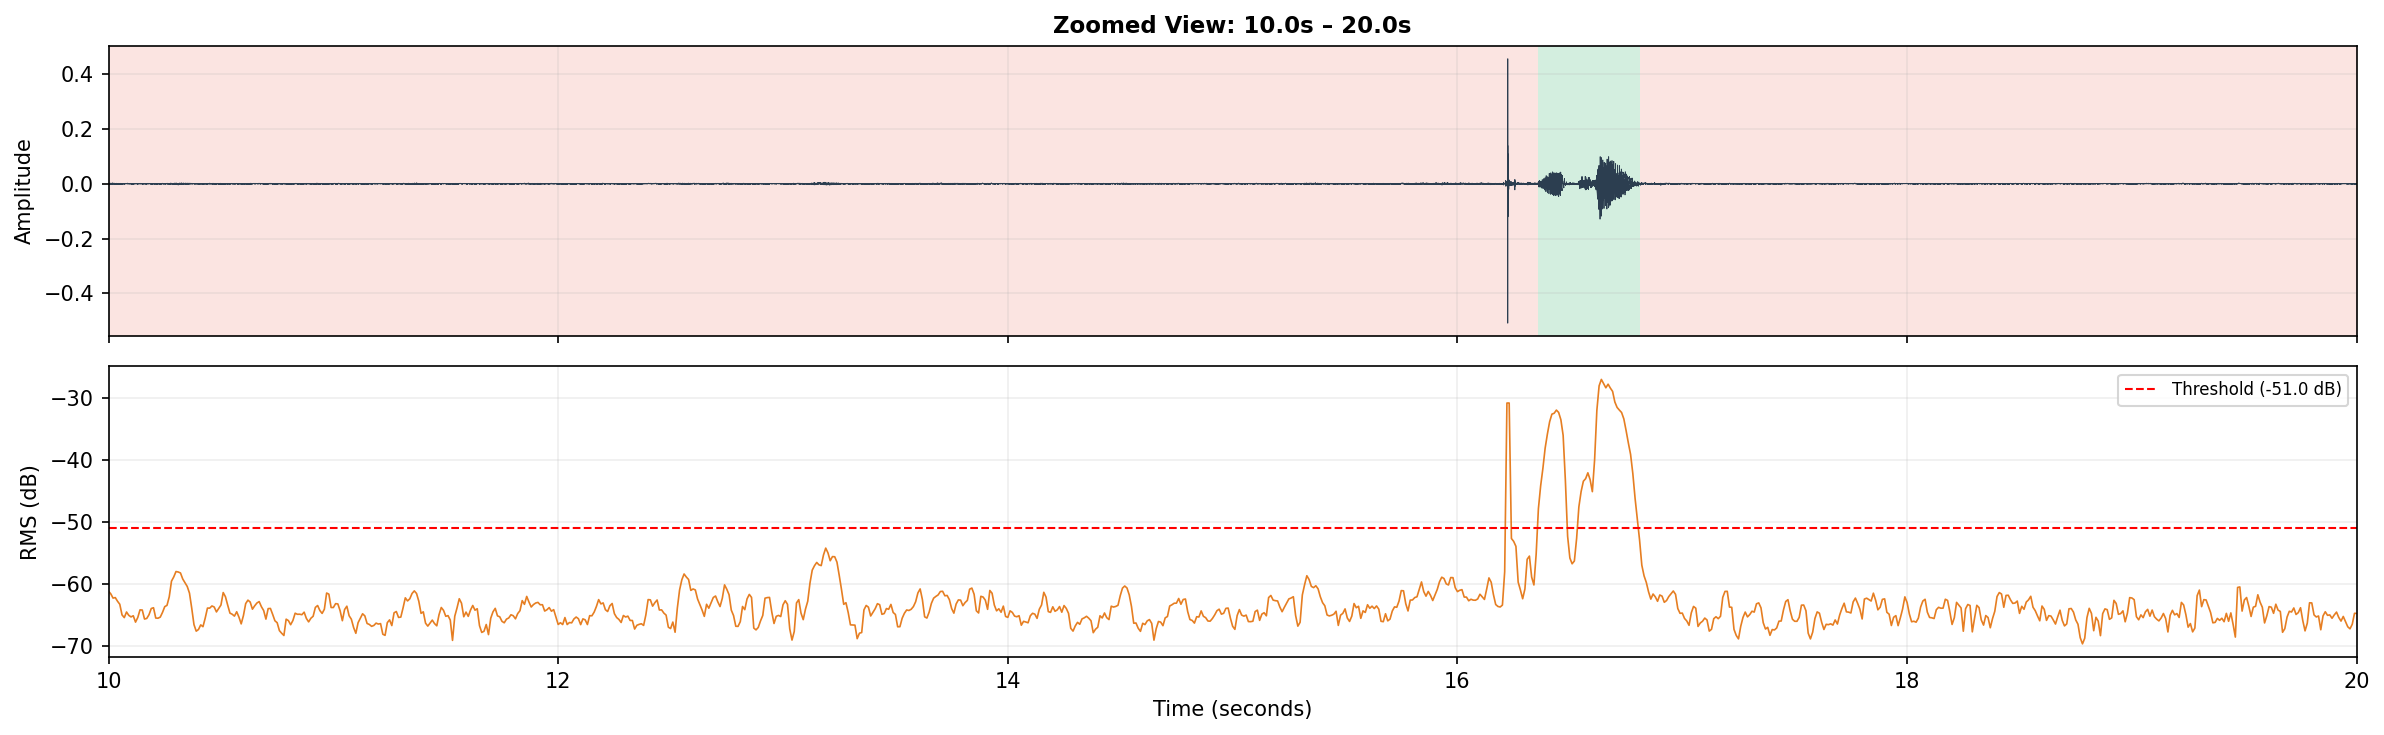

Tip: Change ZOOM_START to inspect different parts of the recording.
     Green = speech, Red = silence. Verify visually that the VAD looks correct.
     If too many speech frames are missed, try lowering THRESHOLD_MARGIN_DB (currently 15 dB).
     If too much noise is classified as speech, try raising it.


In [16]:
# ============================================================
# 4. Zoomed view of a 10-second window
# ============================================================
ZOOM_START = 10.0   # seconds — adjust this to look at different parts
ZOOM_END   = min(ZOOM_START + 10.0, duration)

fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

# Waveform with speech/silence shading
ax = axes[0]
mask = (time_axis >= ZOOM_START) & (time_axis <= ZOOM_END)
ax.plot(time_axis[mask], y[mask], linewidth=0.4, color='#2C3E50')

for i in range(len(vad_final)):
    t = rms_times[i]
    if t < ZOOM_START or t > ZOOM_END:
        continue
    t_end = t + hop_length / sr
    color = '#27AE60' if vad_final[i] > 0.5 else '#E74C3C'
    alpha = 0.2 if vad_final[i] > 0.5 else 0.15
    ax.axvspan(t, t_end, alpha=alpha, color=color, linewidth=0)

ax.set_ylabel('Amplitude')
ax.set_title(f'Zoomed View: {ZOOM_START:.1f}s – {ZOOM_END:.1f}s')
ax.set_xlim(ZOOM_START, ZOOM_END)

# Energy with threshold
ax = axes[1]
mask_rms = (rms_times >= ZOOM_START) & (rms_times <= ZOOM_END)
ax.plot(rms_times[mask_rms], rms_db[mask_rms], linewidth=0.8, color='#E67E22')
ax.axhline(vad_threshold_db, color='red', ls='--', lw=1, label=f'Threshold ({vad_threshold_db:.1f} dB)')
ax.set_ylabel('RMS (dB)')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right', fontsize=8)

for a in axes:
    a.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Tip: Change ZOOM_START to inspect different parts of the recording.')
print(f'     Green = speech, Red = silence. Verify visually that the VAD looks correct.')
print(f'     If too many speech frames are missed, try lowering THRESHOLD_MARGIN_DB (currently {THRESHOLD_MARGIN_DB} dB).')
print(f'     If too much noise is classified as speech, try raising it.')

---
## Part 5: Parameter Sensitivity

The VAD result depends on the threshold. Let's see how sensitive  
our metrics are to different threshold settings.

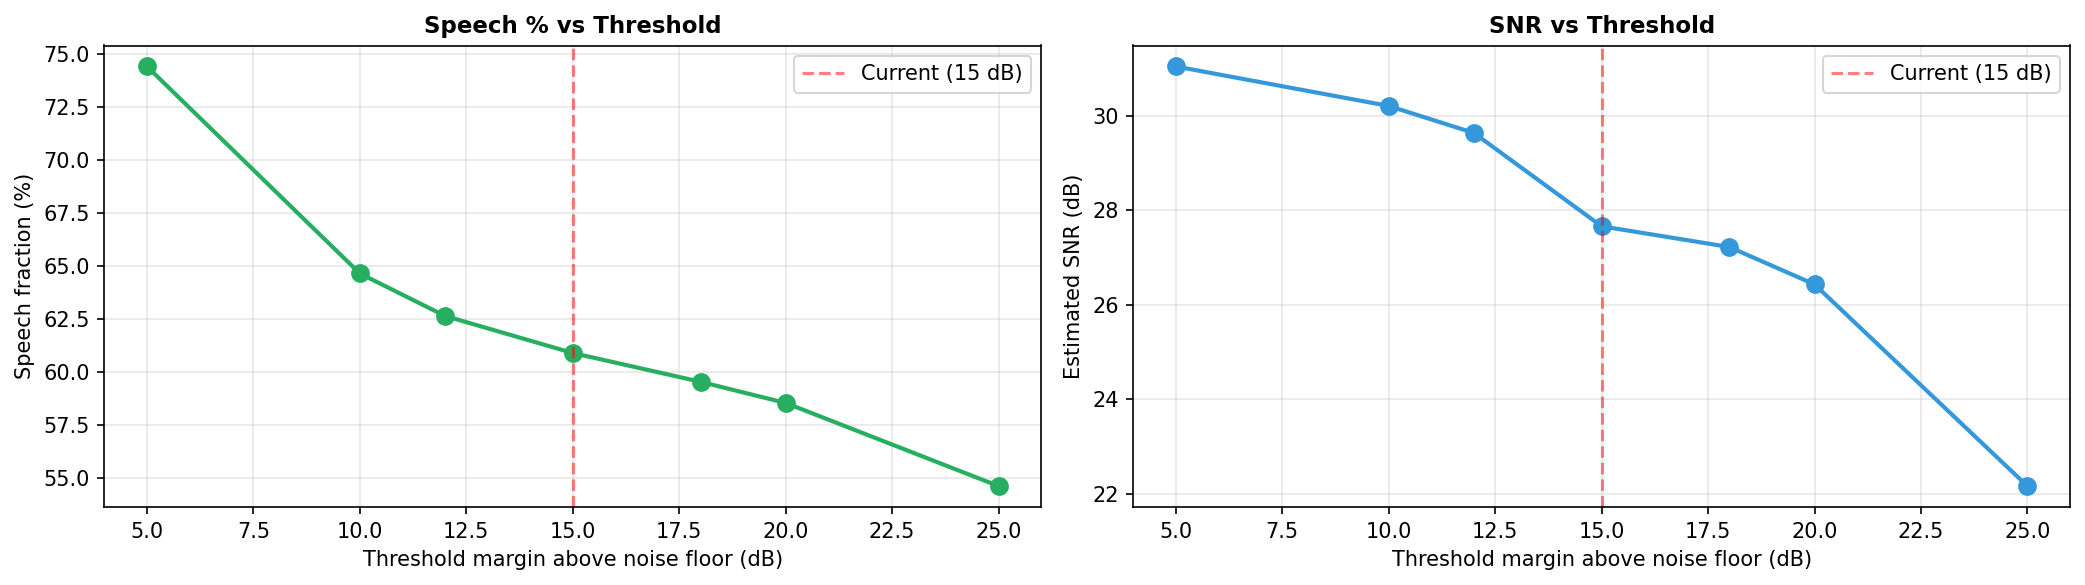


Sensitivity table:
 Margin (dB)  Threshold (dB)   Speech %   SNR (dB)
--------------------------------------------------
           5           -61.0      74.4%      31.0
          10           -56.0      64.6%      30.2
          12           -54.0      62.6%      29.6
          15           -51.0      60.9%      27.7 ← current
          18           -48.0      59.5%      27.2
          20           -46.0      58.5%      26.4
          25           -41.0      54.6%      22.2


In [15]:
# ============================================================
# 5. Sensitivity analysis
# ============================================================
margins = [5, 10, 12, 15, 18, 20, 25]
results = []

for margin in margins:
    thresh = noise_floor_db + margin
    v_raw = (rms_db >= thresh).astype(float)
    v_smooth = ndimage.median_filter(v_raw, size=SMOOTH_FRAMES)
    v_closed = ndimage.binary_closing(v_smooth, structure=np.ones(min_silence_frames)).astype(float)
    v_final  = ndimage.binary_opening(v_closed, structure=np.ones(min_speech_frames)).astype(float)
    
    sf = v_final.mean()
    
    # Compute SNR for this threshold
    s_mask = np.zeros(len(y), dtype=bool)
    for i in range(len(v_final)):
        if v_final[i] > 0.5:
            start = i * hop_length
            end = min(start + frame_length, len(y))
            s_mask[start:end] = True
    
    ps = np.mean(y[s_mask]**2) if s_mask.any() else 1e-20
    pn = np.mean(y[~s_mask]**2) if (~s_mask).any() else 1e-20
    snr = 10 * np.log10(ps / pn)
    
    results.append({
        'margin': margin,
        'threshold': thresh,
        'speech_frac': sf,
        'snr': snr,
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot([r['margin'] for r in results], [r['speech_frac']*100 for r in results],
        'o-', color='#27AE60', linewidth=2, markersize=8)
ax.set_xlabel('Threshold margin above noise floor (dB)')
ax.set_ylabel('Speech fraction (%)')
ax.set_title('Speech % vs Threshold')
ax.axvline(THRESHOLD_MARGIN_DB, color='red', ls='--', alpha=0.5, label=f'Current ({THRESHOLD_MARGIN_DB} dB)')
ax.legend()

ax = axes[1]
ax.plot([r['margin'] for r in results], [r['snr'] for r in results],
        'o-', color='#3498DB', linewidth=2, markersize=8)
ax.set_xlabel('Threshold margin above noise floor (dB)')
ax.set_ylabel('Estimated SNR (dB)')
ax.set_title('SNR vs Threshold')
ax.axvline(THRESHOLD_MARGIN_DB, color='red', ls='--', alpha=0.5, label=f'Current ({THRESHOLD_MARGIN_DB} dB)')
ax.legend()

for a in axes:
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nSensitivity table:')
print(f'{"Margin (dB)":>12} {"Threshold (dB)":>15} {"Speech %":>10} {"SNR (dB)":>10}')
print('-' * 50)
for r in results:
    marker = ' ← current' if r['margin'] == THRESHOLD_MARGIN_DB else ''
    print(f'{r["margin"]:>12} {r["threshold"]:>15.1f} {r["speech_frac"]*100:>9.1f}% {r["snr"]:>9.1f}{marker}')

---
## Summary & Next Steps

### What we computed
1. **Voice Activity Detection** — classified every 10ms frame as speech or silence
2. **Signal-to-Noise Ratio** — estimated from speech power vs noise power
3. **Pause analysis** — extracted every individual pause, computed statistics
4. **Parameter sensitivity** — showed how results vary with threshold choice

### Key metrics for PD detection
From the ParkCeleb paper, the following pause-related metrics showed  
significant changes in PD vs controls:
- **Mean pause duration** (p=0.04, increased in PD)
- **Speech rate** (p=0.002, decreased in PD)
- **Syllable duration** (p=0.01, increased in PD)

### What to do next
- Run this on all KCL files (batch mode) to compare PD vs HC pause patterns
- Verify VAD quality by listening to a few files and checking the zoomed view
- If the threshold doesn't work well for some files, consider adaptive thresholding  
  or a neural VAD (e.g., Silero VAD)
- Combine pause metrics with the acoustic features from Notebook 01  
  for a more comprehensive feature set